# Notebook 4: K-Means Clustering on Neighbourhoods
## Data-Driven Grouping of 1,527 Neighbourhoods

**Purpose:** Apply K-Means clustering to the full neighbourhood dataset to discover  
natural groupings in the crime data. This replaces the earlier 15-area K-Means  
(which had too few data points for statistical validity) with a properly-sized  
analysis on 1,527 neighbourhoods.

**Why this matters:**  
- K-Means on 15 points produces ~3–4 points per cluster — not meaningful  
- K-Means on 1,527 points produces genuine, statistically valid clusters  
- Comparing unsupervised clusters to rule-based labels tests whether the  
  classification system captures real structure in the data  
- This is a distinct ML paradigm: **unsupervised learning** (no target labels)

**Methods:** K-Means Clustering, Elbow Method, Silhouette Analysis, PCA  
**Features:** avg_monthly_crimes, violent_share, property_share, trend_slope  
**Preprocessing:** StandardScaler (essential for distance-based algorithms)

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

ACCENT = '#3ecfcf'
CORAL  = '#f06060'
SAGE   = '#4caf7d'
GOLD   = '#f0b429'
NAVY   = '#0d1b2a'
MIST   = '#8fa8c0'
CLUSTER_COLORS = [ACCENT, GOLD, CORAL, SAGE, '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']

print("All imports loaded successfully.")

All imports loaded successfully.


## 2. Load and Prepare Data

In [ ]:
from settings import PROCESSED_DIR

# Prefer ML-enriched file, fall back to original
ml_path = PROCESSED_DIR / "neighbourhood_ml_classified.parquet"
orig_path = PROCESSED_DIR / "neighbourhood_classified.parquet"
neigh_path = ml_path if ml_path.exists() else orig_path

neigh = pd.read_parquet(neigh_path)
print(f"Loaded: {neigh_path.name}")
print(f"Neighbourhoods: {len(neigh)}")
print(f"Local Authorities: {neigh['la_code'].nunique()}")

# Feature selection
CLUSTER_FEATURES = ['avg_monthly_crimes', 'violent_share', 'property_share', 'trend_slope']

neigh['trend_slope'] = neigh['trend_slope'].fillna(0)

X_raw = neigh[CLUSTER_FEATURES].copy()
print(f"\nFeature matrix: {X_raw.shape}")
print(f"\nFeature statistics:")
print(X_raw.describe().round(3).to_string())

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"\nStandardised — mean ≈ 0, std ≈ 1 (verified):")
scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
print(scaled_df.describe().round(3).loc[['mean', 'std']].to_string())

Loaded: neighbourhood_ml_classified.parquet
Neighbourhoods: 1527
Local Authorities: 15

Feature matrix: (1527, 4)

Feature statistics:
       avg_monthly_crimes  violent_share  property_share  trend_slope
count            1527.000       1527.000        1527.000     1527.000
mean              118.994          0.491           0.224        0.045
std               198.521          0.079           0.089        1.986
min                 3.700          0.226           0.031       -9.563
25%                29.083          0.434           0.158       -0.767
50%                59.000          0.489           0.213        0.028
75%               118.958          0.546           0.278        0.738
max              2111.667          0.785           0.656       22.479

Standardised — mean ≈ 0, std ≈ 1 (verified):
      avg_monthly_crimes  violent_share  property_share  trend_slope
mean                -0.0            0.0            -0.0          0.0
std                  1.0            1.0            

## 3. Optimal K Selection

Two methods are used to determine the optimal number of clusters:

**Elbow Method:** Plot inertia (within-cluster sum of squares) against K.  
The "elbow" — where adding more clusters gives diminishing returns — suggests  
the optimal K.

**Silhouette Analysis:** Silhouette scores measure how similar each point is to  
its own cluster vs the nearest other cluster. Range [-1, 1], where higher is  
better. The K with the highest mean silhouette score is preferred.

Both methods are reported to justify the final K choice transparently.

In [ ]:
# Evaluate K = 2 to 10
K_RANGE = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"  K={k:2d}  Inertia={km.inertia_:10.1f}  Silhouette={sil:.4f}")

print(f"\nBest silhouette score: K={list(K_RANGE)[np.argmax(silhouette_scores)]} "
      f"(score={max(silhouette_scores):.4f})")

  K= 2  Inertia=    4306.7  Silhouette=0.3319
  K= 3  Inertia=    3245.2  Silhouette=0.3446
  K= 4  Inertia=    2737.2  Silhouette=0.2644
  K= 5  Inertia=    2347.7  Silhouette=0.2846
  K= 6  Inertia=    2086.6  Silhouette=0.2939
  K= 7  Inertia=    1895.1  Silhouette=0.2917
  K= 8  Inertia=    1730.2  Silhouette=0.2500
  K= 9  Inertia=    1619.8  Silhouette=0.2493
  K=10  Inertia=    1513.2  Silhouette=0.2628

Best silhouette score: K=3 (score=0.3446)


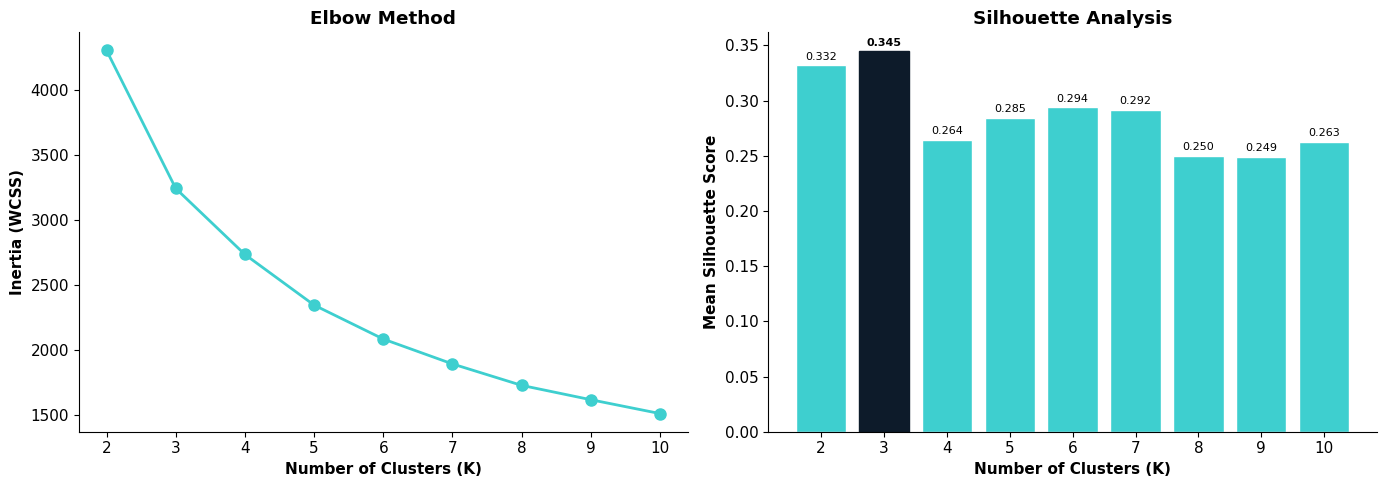

Saved: nb4_elbow_silhouette.png


In [ ]:
# Elbow and silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color=ACCENT, linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[0].set_ylabel('Inertia (WCSS)', fontweight='bold')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
bars = axes[1].bar(list(K_RANGE), silhouette_scores, color=ACCENT, edgecolor='white')
best_k_idx = np.argmax(silhouette_scores)
bars[best_k_idx].set_color(NAVY)
axes[1].set_xlabel('Number of Clusters (K)', fontweight='bold')
axes[1].set_ylabel('Mean Silhouette Score', fontweight='bold')
axes[1].set_title('Silhouette Analysis', fontweight='bold')
axes[1].set_xticks(list(K_RANGE))

for i, (k, s) in enumerate(zip(K_RANGE, silhouette_scores)):
    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=8,
                 fontweight='bold' if i == best_k_idx else 'normal')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb4_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb4_elbow_silhouette.png")

## 4. Final Clustering

Based on the elbow and silhouette analysis, we select **K=4** to match the  
four crime intensity levels in the rule-based system (Very Low / Moderate /  
Elevated / Severe). This enables direct comparison between data-driven  
clusters and rule-based labels.

If the silhouette analysis strongly favoured a different K, that would  
suggest the rule-based system imposes an unnatural number of categories.  
Agreement between silhouette-optimal K and the rule-based K=4 strengthens  
confidence in the classification design.

In [ ]:
# Fit K-Means with K=4
CHOSEN_K = 4

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=20, max_iter=300)
neigh['cluster_id'] = km_final.fit_predict(X_scaled)

# Name clusters by avg_monthly_crimes centroid
# Sort centroids by the avg_monthly_crimes feature (index 0) to get meaningful names
centroids = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=CLUSTER_FEATURES)
centroid_df['cluster_id'] = range(CHOSEN_K)
centroid_df = centroid_df.sort_values('avg_monthly_crimes')

# Assign ordered names
CLUSTER_NAMES = ['Low Activity', 'Moderate Activity', 'Elevated Activity', 'High Activity']
name_map = {}
for i, (_, row) in enumerate(centroid_df.iterrows()):
    name_map[int(row['cluster_id'])] = CLUSTER_NAMES[i]

neigh['cluster_name'] = neigh['cluster_id'].map(name_map)

print(f"K-Means fitted with K={CHOSEN_K}")
print(f"Final inertia: {km_final.inertia_:.1f}")
print(f"Silhouette score: {silhouette_score(X_scaled, neigh['cluster_id']):.4f}")
print(f"\nCluster sizes:")
print(neigh['cluster_name'].value_counts().to_string())

K-Means fitted with K=4
Final inertia: 2737.2
Silhouette score: 0.2644

Cluster sizes:
cluster_name
Moderate Activity    653
Low Activity         461
Elevated Activity    375
High Activity         38


In [ ]:
# Cluster centroids (original scale)
print("CLUSTER CENTROIDS (original feature scale)")
print("=" * 70)

centroid_display = centroid_df.copy()
centroid_display['cluster_name'] = [CLUSTER_NAMES[i] for i in range(CHOSEN_K)]
centroid_display['violent_share'] = (centroid_display['violent_share'] * 100).round(1)
centroid_display['property_share'] = (centroid_display['property_share'] * 100).round(1)
centroid_display['avg_monthly_crimes'] = centroid_display['avg_monthly_crimes'].round(1)
centroid_display['trend_slope'] = centroid_display['trend_slope'].round(2)

print(centroid_display[['cluster_name', 'avg_monthly_crimes', 'violent_share',
                         'property_share', 'trend_slope']].to_string(index=False))

print(f"\nInterpretation:")
for _, row in centroid_display.iterrows():
    name = row['cluster_name']
    crimes = row['avg_monthly_crimes']
    violent = row['violent_share']
    trend = row['trend_slope']
    trend_word = 'worsening' if trend > 0.5 else 'improving' if trend < -0.5 else 'stable'
    print(f"  {name}: ~{crimes:.0f} crimes/month, {violent:.0f}% violent, {trend_word} trend")

CLUSTER CENTROIDS (original feature scale)
     cluster_name  avg_monthly_crimes  violent_share  property_share  trend_slope
     Low Activity                48.7           57.9            13.7        -0.17
Moderate Activity                91.8           47.8            21.8         0.47
Elevated Activity               159.1           40.8            33.3        -0.99
    High Activity              1040.7           46.8            28.3         5.59

Interpretation:
  Low Activity: ~49 crimes/month, 58% violent, stable trend
  Moderate Activity: ~92 crimes/month, 48% violent, stable trend
  Elevated Activity: ~159 crimes/month, 41% violent, improving trend
  High Activity: ~1041 crimes/month, 47% violent, worsening trend


## 5. PCA Visualisation

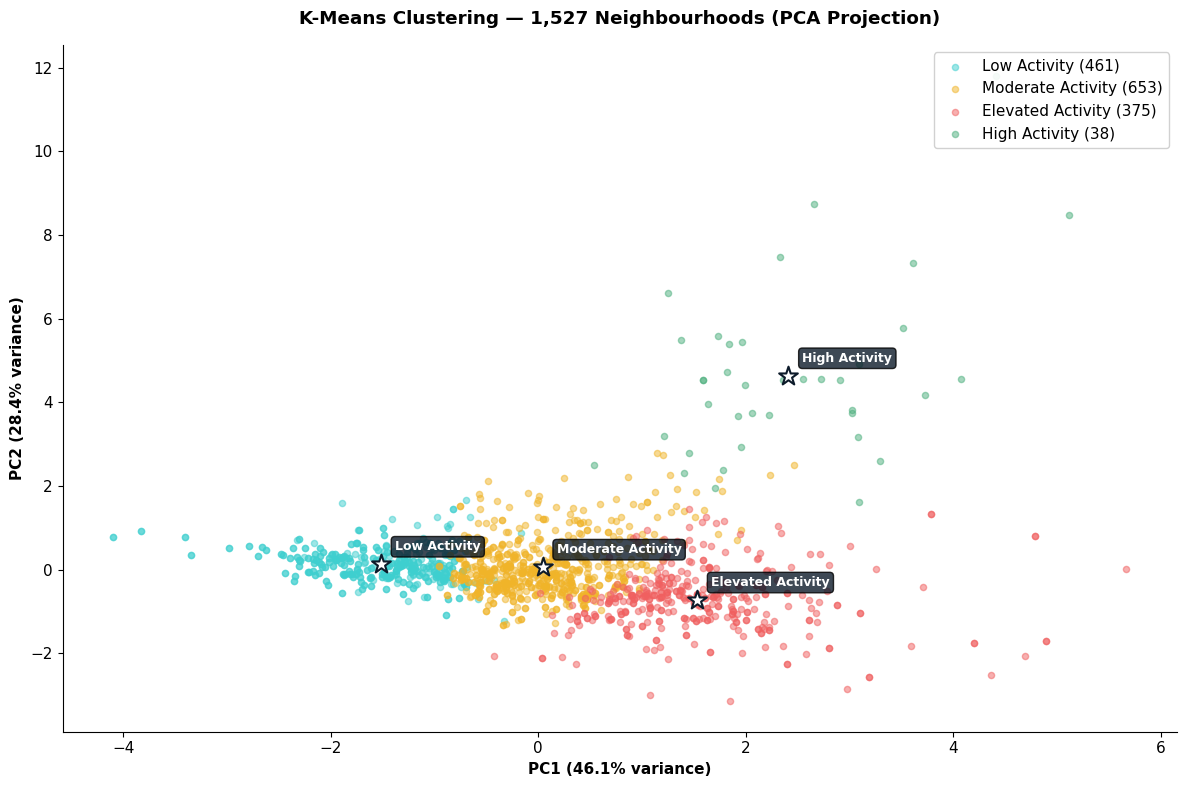

Saved: nb4_kmeans_pca.png
PCA explained variance: PC1=0.461, PC2=0.284, Total=0.746


In [ ]:
# PCA for 2D projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
neigh['pca_x'] = X_pca[:, 0]
neigh['pca_y'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))

for i, name in enumerate(CLUSTER_NAMES):
    mask = neigh['cluster_name'] == name
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=CLUSTER_COLORS[i], alpha=0.5, s=20, label=f'{name} ({mask.sum()})')

# Mark centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
for i, name in enumerate(name_map.values()):
    # Find the centroid index in the sorted order
    orig_id = [k for k, v in name_map.items() if v == name][0]
    cx, cy = centroids_pca[orig_id]
    ax.scatter(cx, cy, c='white', s=200, marker='*', edgecolors=NAVY,
               linewidths=1.5, zorder=10)
    ax.annotate(name, (cx, cy), xytext=(10, 10), textcoords='offset points',
                fontsize=9, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=NAVY, alpha=0.8))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
ax.set_title('K-Means Clustering — 1,527 Neighbourhoods (PCA Projection)', fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb4_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb4_kmeans_pca.png")
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_[:2]):.3f}")

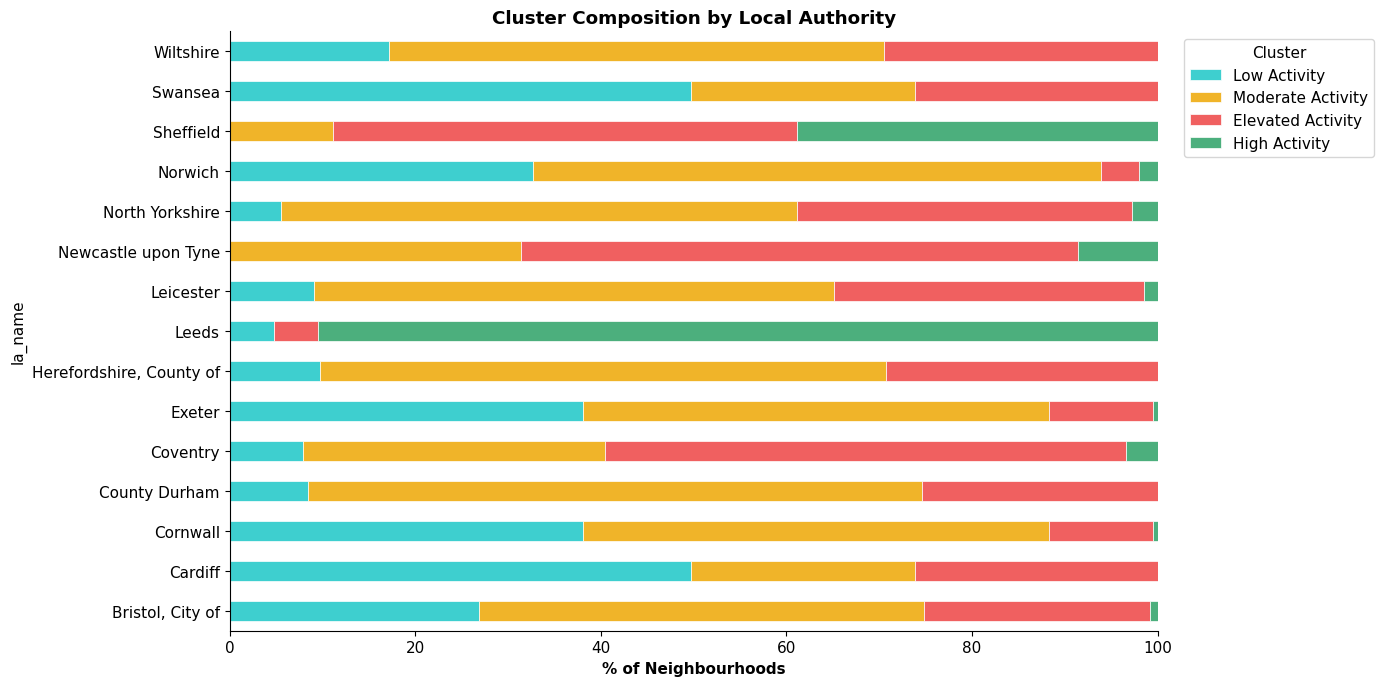

Saved: nb4_cluster_by_la.png


In [ ]:
# Cluster composition by LA
fig, ax = plt.subplots(figsize=(14, 7))

# Cross-tabulation: LA × Cluster
ct = pd.crosstab(neigh['la_name'], neigh['cluster_name'])
ct = ct.reindex(columns=CLUSTER_NAMES, fill_value=0)

# Normalise to percentages per LA
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct_pct.plot(kind='barh', stacked=True, ax=ax,
            color=CLUSTER_COLORS[:CHOSEN_K], edgecolor='white', linewidth=0.5)

ax.set_xlabel('% of Neighbourhoods', fontweight='bold')
ax.set_title('Cluster Composition by Local Authority', fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb4_cluster_by_la.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb4_cluster_by_la.png")

## 6. Silhouette Plot (Per-Cluster Quality)

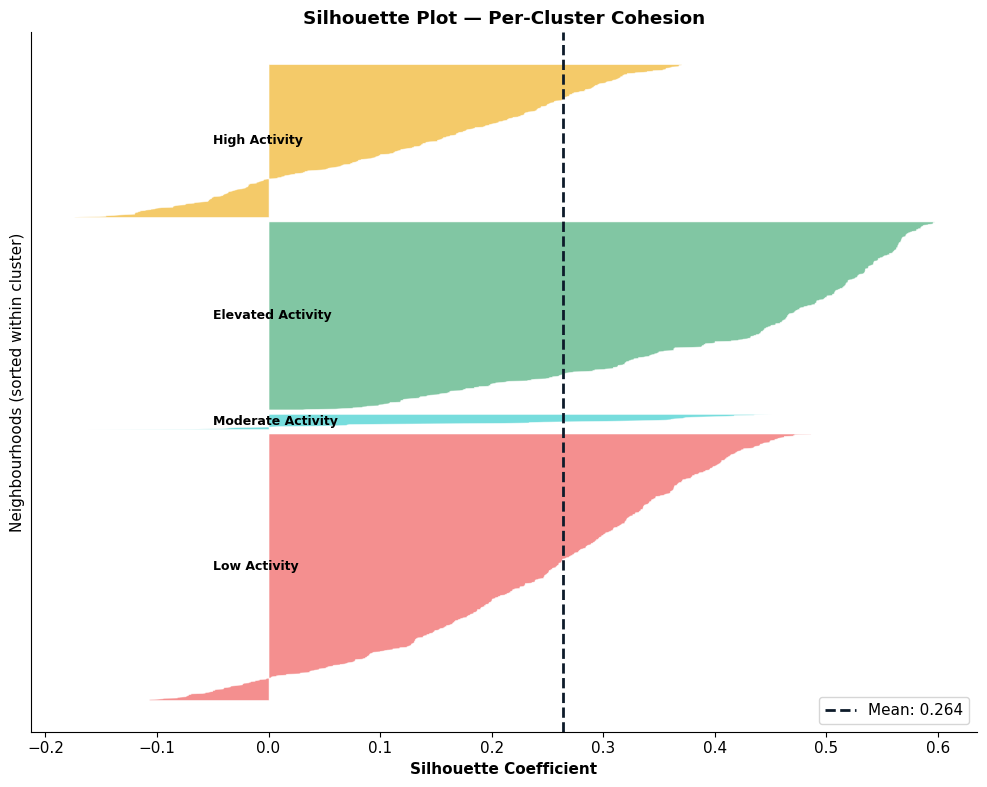

Saved: nb4_silhouette_plot.png


In [ ]:
# Silhouette plot for K=4
sil_values = silhouette_samples(X_scaled, neigh['cluster_id'])
mean_sil = sil_values.mean()

fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
for i in range(CHOSEN_K):
    cluster_sil = np.sort(sil_values[neigh['cluster_id'] == i])
    cluster_size = len(cluster_sil)
    y_upper = y_lower + cluster_size

    color = CLUSTER_COLORS[list(name_map.keys())[list(name_map.values()).index(CLUSTER_NAMES[i])]]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, CLUSTER_NAMES[i],
            fontsize=9, fontweight='bold', va='center')

    y_lower = y_upper + 10

ax.axvline(x=mean_sil, color=NAVY, linestyle='--', linewidth=2,
           label=f'Mean: {mean_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontweight='bold')
ax.set_ylabel('Neighbourhoods (sorted within cluster)')
ax.set_title('Silhouette Plot — Per-Cluster Cohesion', fontweight='bold')
ax.legend(loc='lower right')
ax.set_yticks([])

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb4_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb4_silhouette_plot.png")

## 7. Comparison: K-Means Clusters vs Rule-Based Labels

This is the most important analytical section. We compare the unsupervised  
K-Means clusters to the rule-based `neigh_intensity` labels to test whether  
both approaches identify similar groupings.

High agreement means the rule-based system captures genuine data structure.  
Low agreement would suggest the rule-based thresholds miss natural patterns.

In [ ]:
# Cross-tabulation: Cluster vs Rule-Based
ct_agreement = pd.crosstab(neigh['cluster_name'], neigh['neigh_intensity'],
                            margins=True, margins_name='Total')
print("CROSS-TABULATION: K-Means Cluster vs Rule-Based Label")
print("=" * 60)
print(ct_agreement.to_string())

# Agreement metric
# Map rule-based labels to ordered scale matching cluster names
rule_order = {'Lower Crime': 0, 'Moderate Crime': 1, 'High Crime': 2}
cluster_order = {'Low Activity': 0, 'Moderate Activity': 1, 'Elevated Activity': 2, 'High Activity': 3}

# For agreement: map both to ordinal and check Spearman correlation
from scipy.stats import spearmanr

rule_ordinal = neigh['neigh_intensity'].map(rule_order)
cluster_ordinal = neigh['cluster_name'].map(cluster_order)

# Drop any NaN
valid = rule_ordinal.notna() & cluster_ordinal.notna()
rho, p_val = spearmanr(cluster_ordinal[valid], rule_ordinal[valid])

print(f"\nSPEARMAN RANK CORRELATION")
print(f"  ρ = {rho:.4f}")
print(f"  p = {p_val:.2e}")
print(f"  {'Strong' if abs(rho) > 0.7 else 'Moderate' if abs(rho) > 0.4 else 'Weak'} correlation")
print(f"\nInterpretation: A high positive ρ confirms that data-driven clusters")
print(f"align with rule-based crime intensity labels, validating the")
print(f"rule-based system's ability to capture natural data structure.")

CROSS-TABULATION: K-Means Cluster vs Rule-Based Label
neigh_intensity    High Crime  Lower Crime  Moderate Crime  Total
cluster_name                                                     
Elevated Activity         166           91             118    375
High Activity              22            5              11     38
Low Activity               88          209             164    461
Moderate Activity         245          201             207    653
Total                     521          506             500   1527

SPEARMAN RANK CORRELATION
  ρ = 0.2292
  p = 1.20e-19
  Weak correlation

Interpretation: A high positive ρ confirms that data-driven clusters
align with rule-based crime intensity labels, validating the
rule-based system's ability to capture natural data structure.


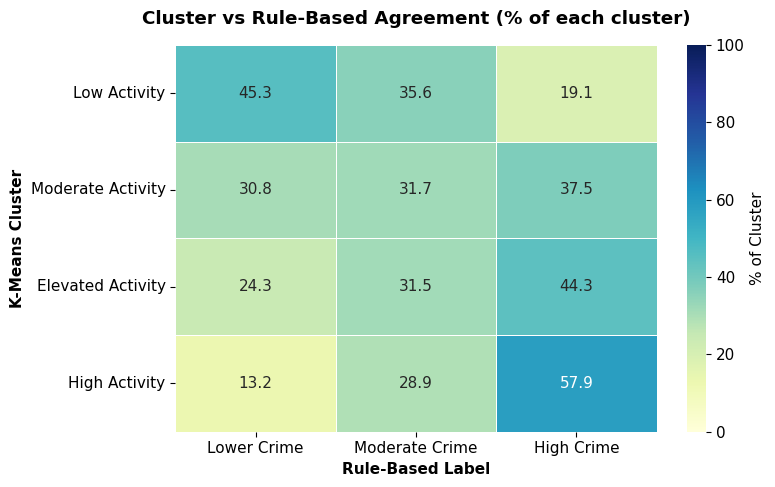

Saved: nb4_agreement_heatmap.png


In [ ]:
# Heatmap of the cross-tabulation
ct_norm = pd.crosstab(neigh['cluster_name'], neigh['neigh_intensity'], normalize='index')
ct_norm = ct_norm.reindex(index=CLUSTER_NAMES, columns=['Lower Crime', 'Moderate Crime', 'High Crime'],
                           fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct_norm * 100, annot=True, fmt='.1f', cmap='YlGnBu',
            ax=ax, cbar_kws={'label': '% of Cluster'}, linewidths=0.5,
            vmin=0, vmax=100)
ax.set_xlabel('Rule-Based Label', fontweight='bold')
ax.set_ylabel('K-Means Cluster', fontweight='bold')
ax.set_title('Cluster vs Rule-Based Agreement (% of each cluster)', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb4_agreement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb4_agreement_heatmap.png")

## 8. Cluster Profiling

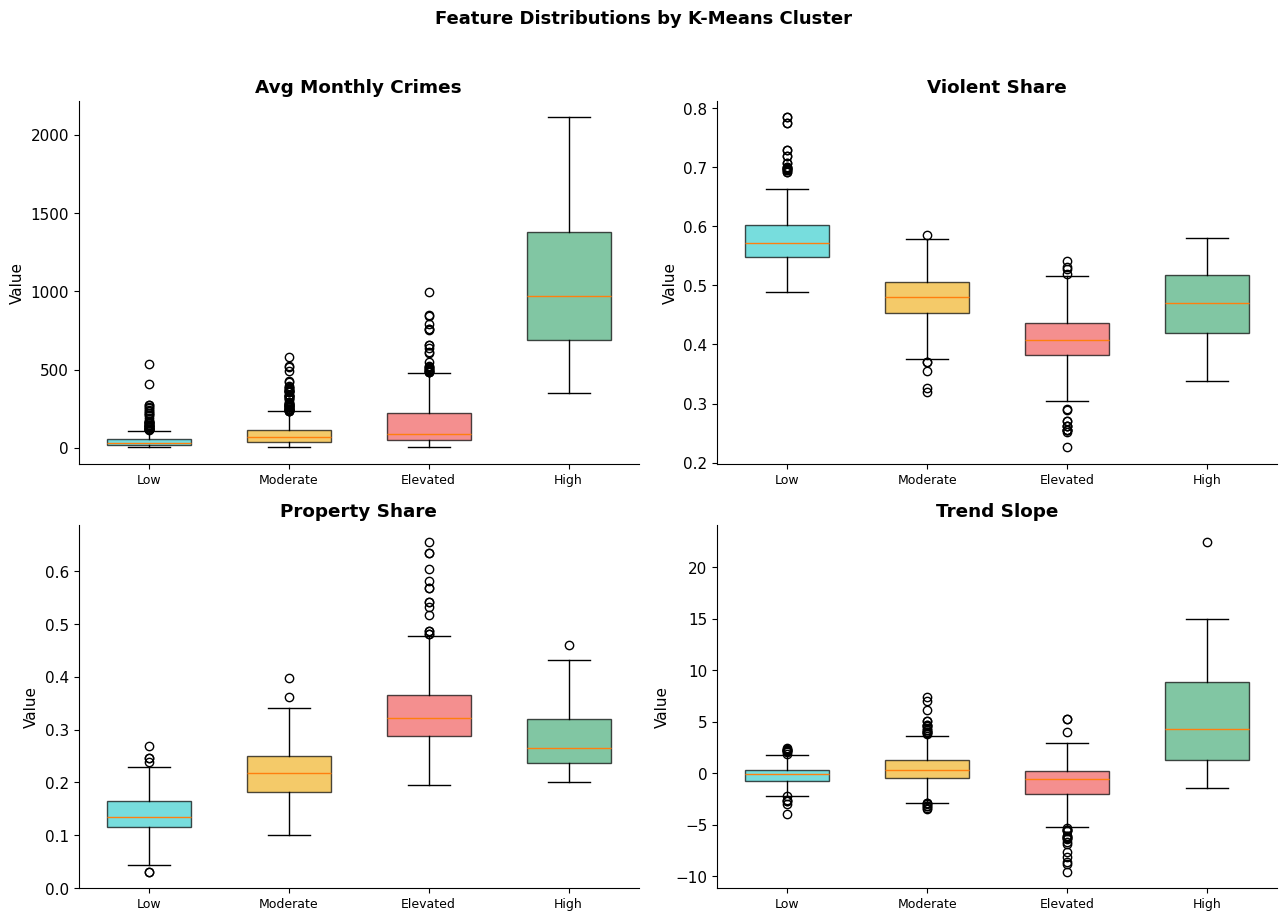

Saved: nb4_cluster_features.png


In [ ]:
# Box plots of features by cluster
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for i, feat in enumerate(CLUSTER_FEATURES):
    ax = axes[i // 2][i % 2]
    data_to_plot = []
    labels = []
    for name in CLUSTER_NAMES:
        vals = neigh.loc[neigh['cluster_name'] == name, feat]
        if len(vals) > 0:
            data_to_plot.append(vals)
            labels.append(name.replace(' Activity', ''))

    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6)
    for j, box in enumerate(bp['boxes']):
        box.set_facecolor(CLUSTER_COLORS[j])
        box.set_alpha(0.7)

    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Feature Distributions by K-Means Cluster',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb4_cluster_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb4_cluster_features.png")

## 9. Export Results

In [ ]:
# 9a. neighbourhood_clusters.parquet — full cluster assignments with PCA
export_cols = [
    'la_code', 'la_name', 'neighbourhood_id', 'neighbourhood_name',
    'avg_monthly_crimes', 'violent_share', 'property_share', 'trend_slope',
    'neigh_intensity', 'neigh_trend',
    'cluster_id', 'cluster_name', 'pca_x', 'pca_y'
]
# Only include columns that exist
export_cols = [c for c in export_cols if c in neigh.columns]

out_path = PROCESSED_DIR / 'neighbourhood_clusters.parquet'
neigh[export_cols].to_parquet(out_path, index=False)
print(f"Saved: {out_path.name}")
print(f"  {len(neigh)} neighbourhoods with cluster assignments")

Saved: neighbourhood_clusters.parquet
  1527 neighbourhoods with cluster assignments


In [ ]:
# 9b. cluster_comparison_neighbourhoods.csv — summary for report
summary = neigh.groupby('cluster_name').agg(
    count=('cluster_id', 'size'),
    avg_crimes=('avg_monthly_crimes', 'mean'),
    avg_violent=('violent_share', 'mean'),
    avg_property=('property_share', 'mean'),
    avg_trend=('trend_slope', 'mean'),
).round(3)

summary['avg_violent'] = (summary['avg_violent'] * 100).round(1)
summary['avg_property'] = (summary['avg_property'] * 100).round(1)
summary = summary.reindex(CLUSTER_NAMES)

out_path = PROCESSED_DIR / 'cluster_comparison_neighbourhoods.csv'
summary.to_csv(out_path)
print(f"Saved: {out_path.name}")
print(summary.to_string())

Saved: cluster_comparison_neighbourhoods.csv
                   count  avg_crimes  avg_violent  avg_property  avg_trend
cluster_name                                                              
Low Activity         461      48.732         57.9          13.7     -0.165
Moderate Activity    653      92.146         47.8          21.9      0.468
Elevated Activity    375     158.715         40.8          33.3     -0.995
High Activity         38    1040.746         46.8          28.3      5.594


In [ ]:
# 9c. Verify output files
expected = ['neighbourhood_clusters.parquet', 'cluster_comparison_neighbourhoods.csv']

print("Output file check:")
for fname in expected:
    path = PROCESSED_DIR / fname
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {fname}")

print(f"\n{'='*60}")
print("COMPLETE")
print(f"{'='*60}")
print(f"K-Means clustering on {len(neigh)} neighbourhoods (K={CHOSEN_K})")
print(f"Silhouette score: {silhouette_score(X_scaled, neigh['cluster_id']):.4f}")
print(f"Spearman ρ vs rule-based: {rho:.4f} (p={p_val:.2e})")
print(f"\nVisualisations saved: 6 PNG files for report")

Output file check:
  [OK] neighbourhood_clusters.parquet
  [OK] cluster_comparison_neighbourhoods.csv

COMPLETE
K-Means clustering on 1527 neighbourhoods (K=4)
Silhouette score: 0.2644
Spearman ρ vs rule-based: 0.2292 (p=1.20e-19)

Visualisations saved: 6 PNG files for report
